## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

LOAD THE DATASET:

In [95]:
import os
os.listdir()

df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [96]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


its weird that there are no nulls, so I will check for "unknown"

In [97]:
(df == "unknown").sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


Identify Numeric vs Categorical Features

In [98]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric Features:\n", numeric_features)
print("\nCategorical Features:\n", categorical_features)

Numeric Features:
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Categorical Features:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


Numeric Feature Analysis

In [99]:
#Basic Statistics

df[numeric_features].describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


features needs to be normalized because they have huge differences in the values

In [100]:
#skewness

df[numeric_features].skew()

,0
age,0.784697
duration,3.263141
campaign,4.762507
pdays,-4.922190
previous,3.832042
emp.var.rate,-0.724096
cons.price.idx,-0.230888
cons.conf.idx,0.303180
euribor3m,-0.709188
nr.employed,-1.044262


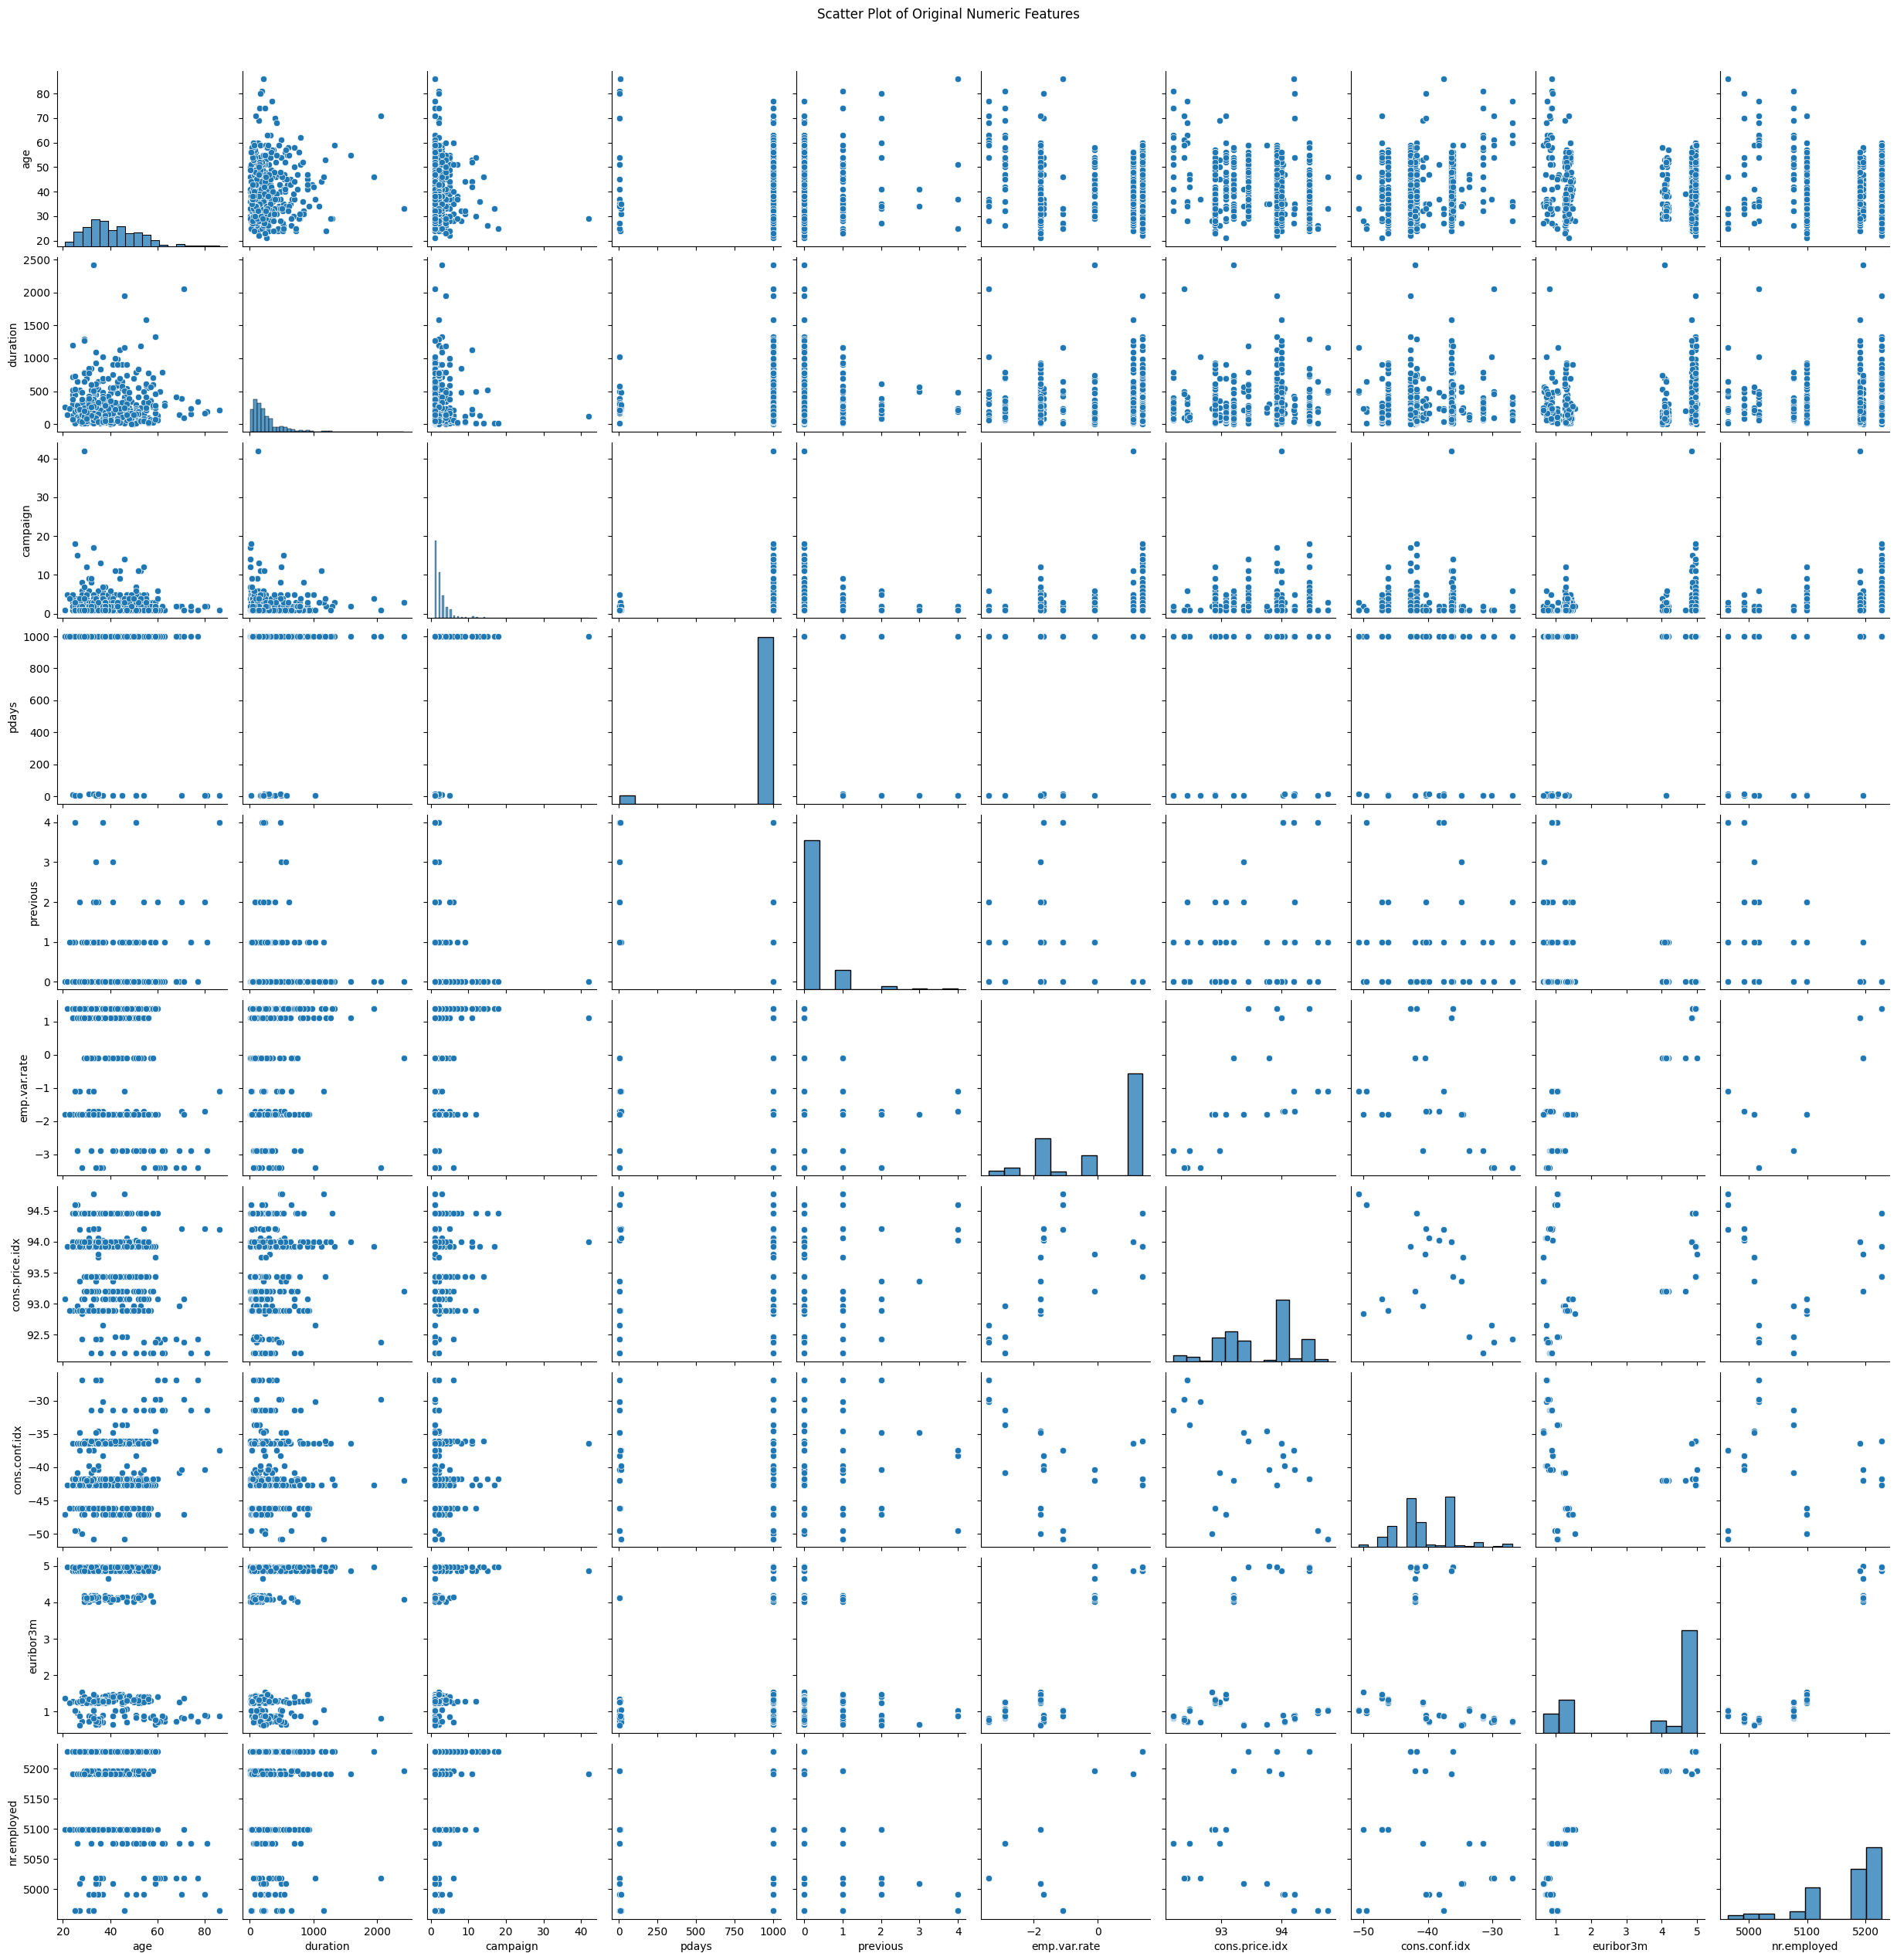

In [101]:
# Select numeric columns in the original df
numeric_cols_original = ['age', 'duration', 'campaign', 'pdays', 'previous',
                         'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                         'euribor3m', 'nr.employed']

# Sample 500 rows for readability
df_sample = df[numeric_cols_original].sample(500, random_state=42)

# Pairwise scatter plots
sns.pairplot(df_sample, kind='scatter', diag_kind='hist')
plt.suptitle("Scatter Plot of Original Numeric Features", y=1.02)
plt.show()

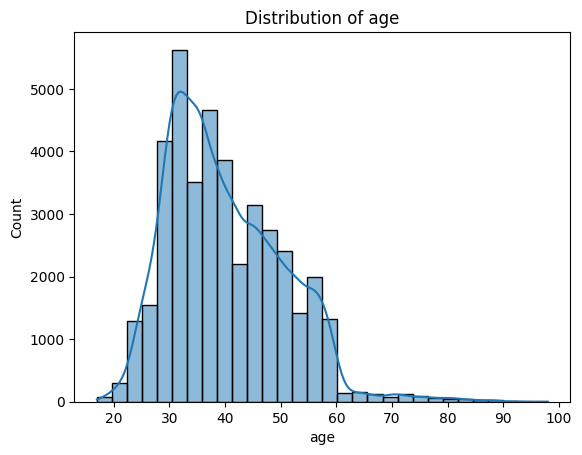

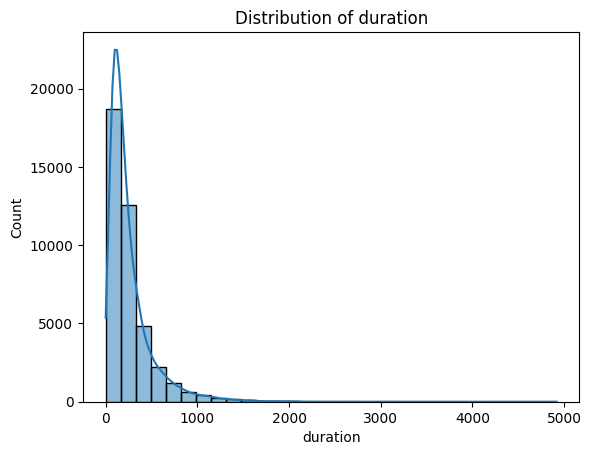

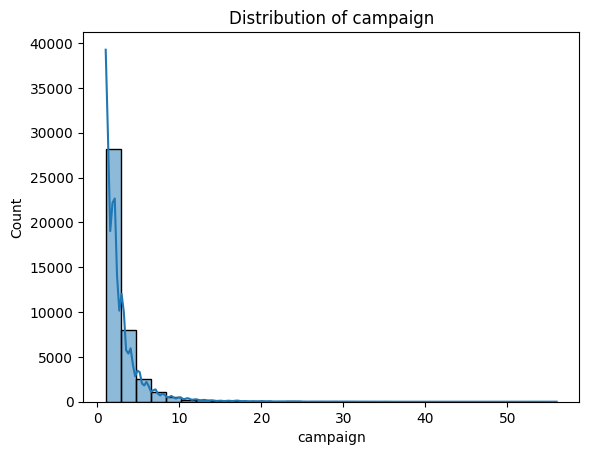

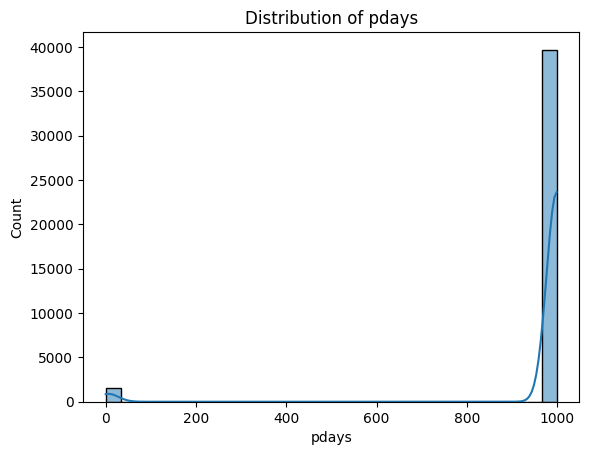

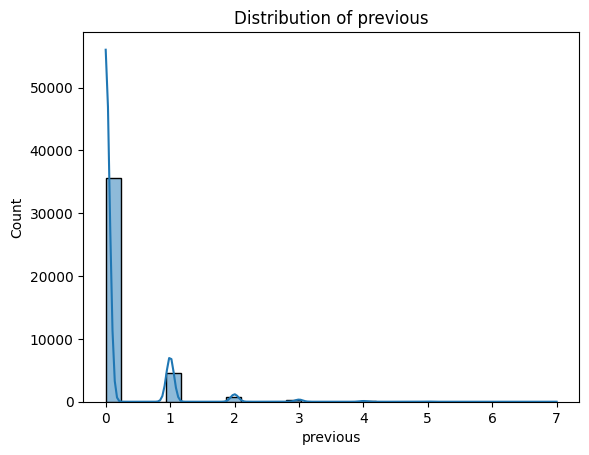

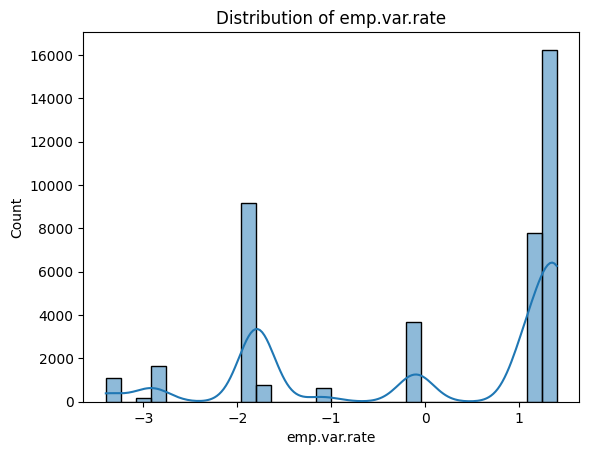

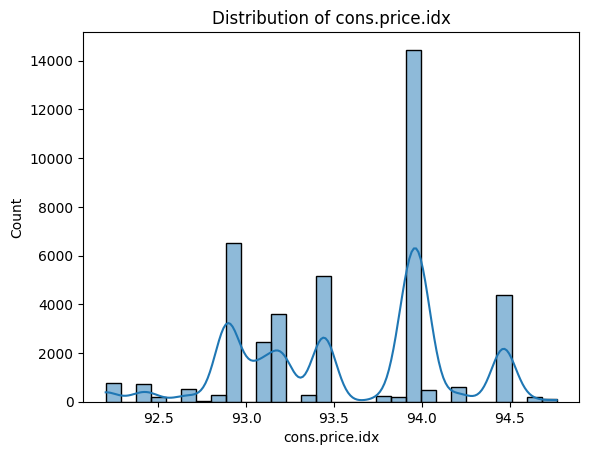

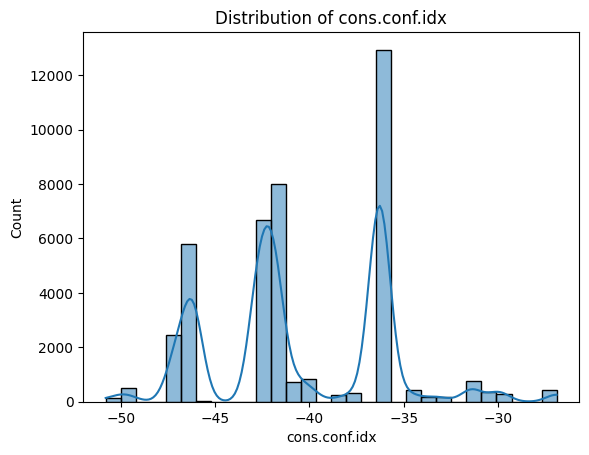

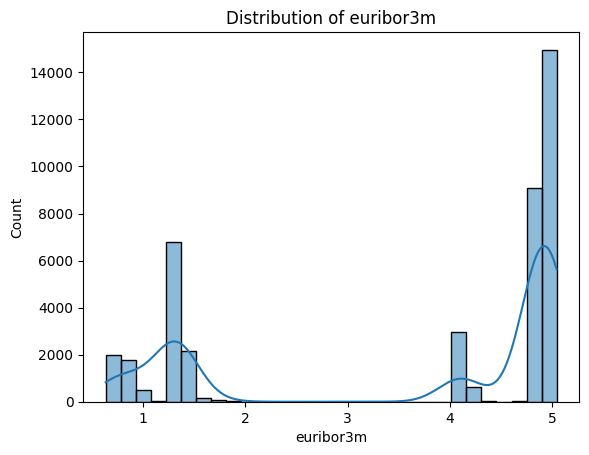

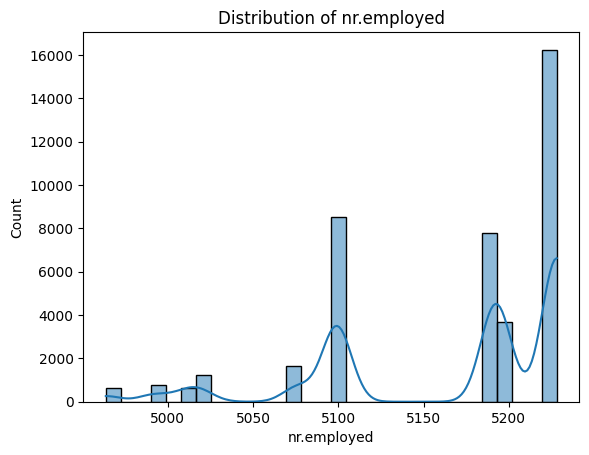

In [102]:
for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [103]:
#checking the counts of the categorical features

for col in categorical_features:
    print(f"\nCategory counts for {col}:")
    print(df[col].value_counts())


Category counts for job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Category counts for marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Category counts for education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Category counts for default:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Category counts for housing:
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

C

In [104]:
# Pearson correlation
correlation_matrix = df[numeric_features].corr()
correlation_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


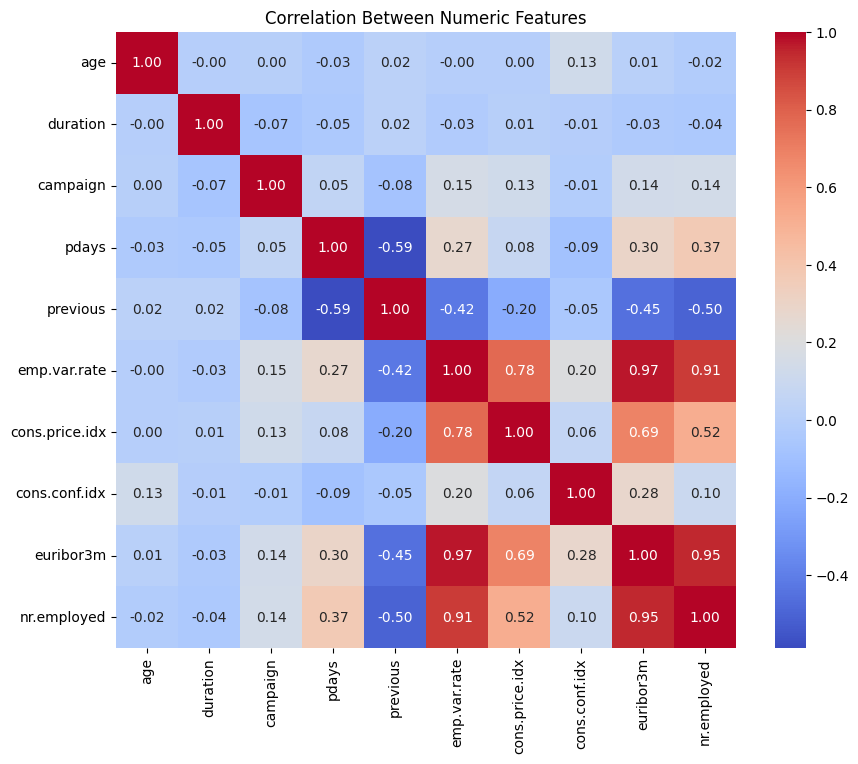

In [105]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

In [106]:
threshold = 0.8
corr_pairs = correlation_matrix.abs().unstack().sort_values(ascending=False)
high_corr = corr_pairs[(corr_pairs < 1) & (corr_pairs > threshold)]
high_corr


emp.var.rate  euribor3m       0.972245
euribor3m     emp.var.rate    0.972245
              nr.employed     0.945154
nr.employed   euribor3m       0.945154
              emp.var.rate    0.906970
emp.var.rate  nr.employed     0.906970
dtype: float64

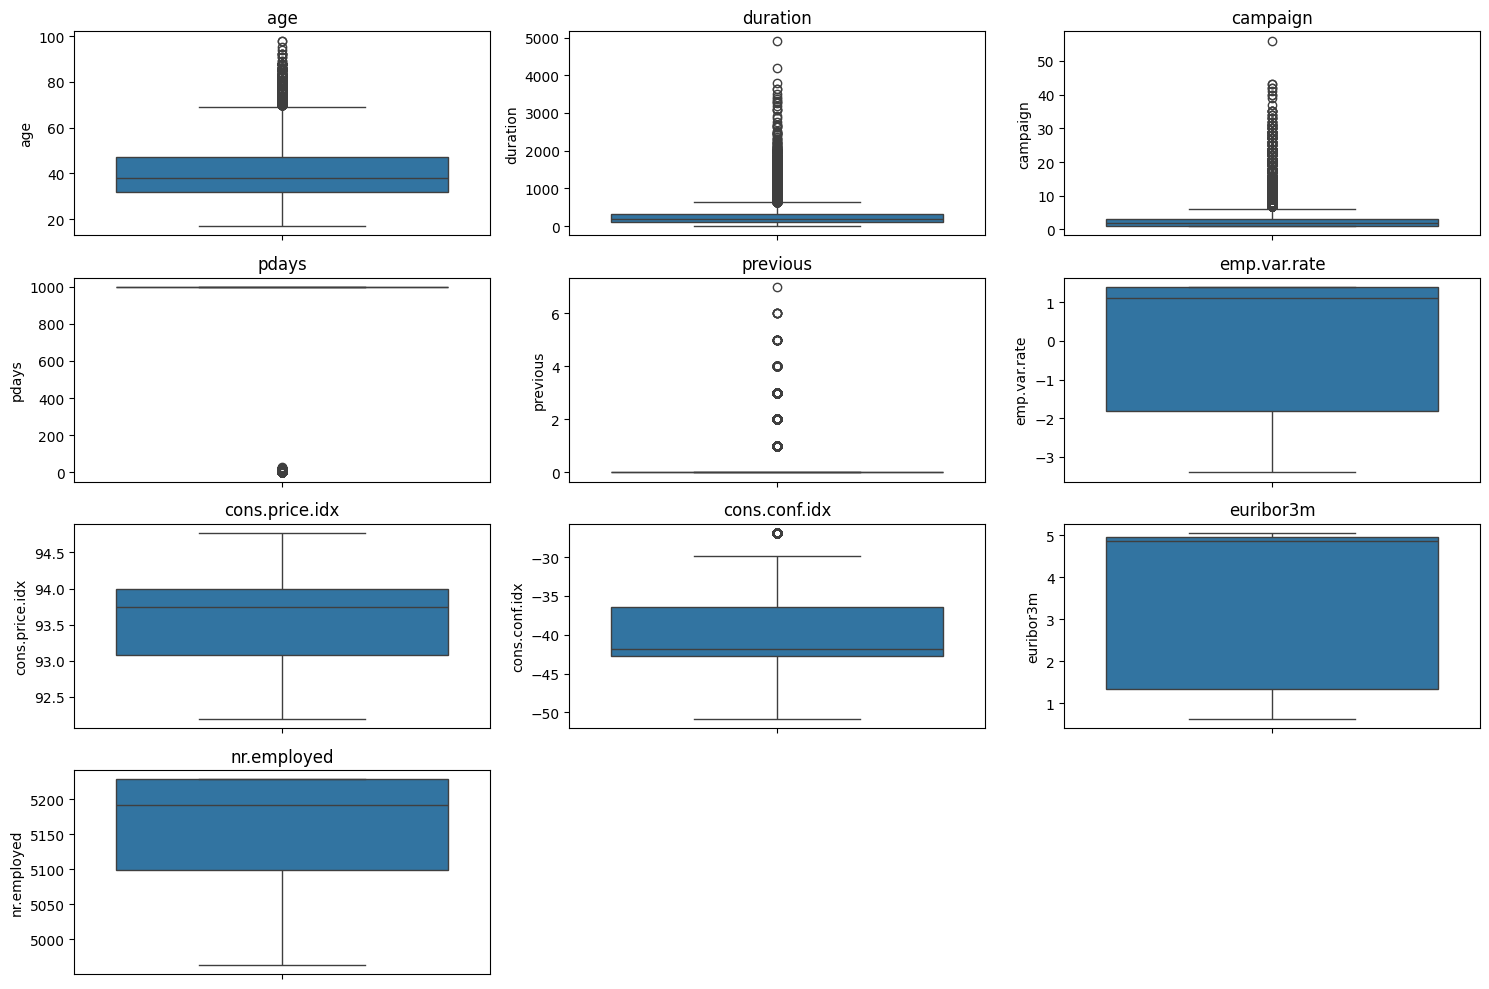

In [107]:
#visualizing for detecting outliers

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_features):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [108]:

# Dictionary to store outliers
outliers_dict = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Get outlier values
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    # Store in dictionary
    outliers_dict[col] = outliers

    print(f"Column: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Some outlier values: {outliers.head(5).values}")
    print("-"*40)

Column: age
Number of outliers: 469
Some outlier values: [70 76 73 88 88]
----------------------------------------
Column: duration
Number of outliers: 2963
Some outlier values: [1666  787  812 1575 1042]
----------------------------------------
Column: campaign
Number of outliers: 2406
Some outlier values: [7 8 8 7 7]
----------------------------------------
Column: pdays
Number of outliers: 1515
Some outlier values: [6 4 4 3 4]
----------------------------------------
Column: previous
Number of outliers: 5625
Some outlier values: [1 1 1 1 1]
----------------------------------------
Column: emp.var.rate
Number of outliers: 0
Some outlier values: []
----------------------------------------
Column: cons.price.idx
Number of outliers: 0
Some outlier values: []
----------------------------------------
Column: cons.conf.idx
Number of outliers: 447
Some outlier values: [-26.9 -26.9 -26.9 -26.9 -26.9]
----------------------------------------
Column: euribor3m
Number of outliers: 0
Some outlie

# Outlier Handling Strategy for Numeric Features

1. **age**  
   - Outliers: elderly clients (70–98 years).  
   - Strategy: Keep all values; K-Means can handle it if we scale.
   
2. **duration**  
   - Outliers: extremely long call durations (>1,500 seconds).  
   - Strategy: Cap values at Q3 + 1.5*IQR (Winsorization). Note: duration is unknown before a call, so only include for clustering benchmarks.

3. **campaign**  
   - Outliers: clients contacted many times (>7–8).  
   - Strategy: Cap at Q3 + 1.5*IQR to avoid skewing clustering.

4. **pdays**  
   - Outliers: clients with very small `pdays` (recently contacted).  
   - Strategy: Treat 999 as "never contacted" special value. Cap unusually low values at Q1 - 1.5*IQR.

5. **previous**  
   - Outliers: clients with multiple previous contacts (>2).  
   - Strategy: Cap at Q3 + 1.5*IQR.

6. **emp.var.rate**, **cons.price.idx**, **euribor3m**, **nr.employed**  
   - No detected outliers.  
   - Strategy: No capping needed; scale as usual.

7. **cons.conf.idx**  
   - Outliers: extreme negative confidence index values (-26.9).  
   - Strategy: Cap at Q1 - 1.5*IQR.

> After capping outliers, we will scale all numeric features for clustering.

In [109]:
# Function to cap outliers using IQR
def cap_outliers(df, col):
    """
    Caps outliers in a column based on the IQR method (1.5*IQR rule).
    Values above the upper bound are set to the upper bound.
    Values below the lower bound are set to the lower bound.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping column by column
# Special notes:
# - 'pdays' 999 is treated as 'never contacted', so we exclude it from lower bound capping
# - Columns with no outliers are still passed through, no change occurs
for col in numeric_features:
    if col == 'pdays':
        # Only cap values less than 999
        mask = df[col] != 999
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df.loc[mask, col] = df.loc[mask, col].clip(lower=lower_bound, upper=upper_bound)
    else:
        df = cap_outliers(df, col)

print("Outlier capping completed for all numeric columns.")

Outlier capping completed for all numeric columns.


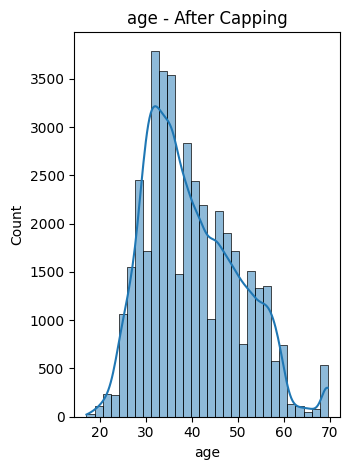

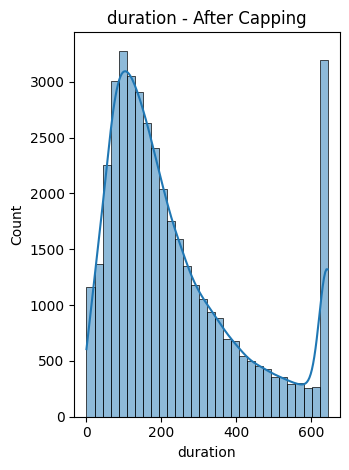

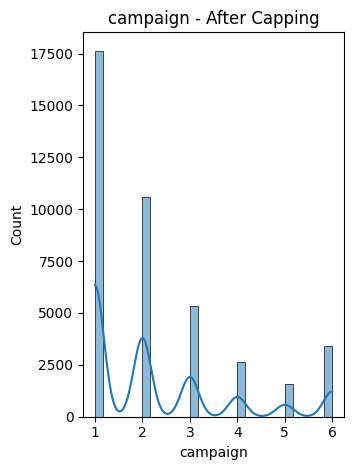

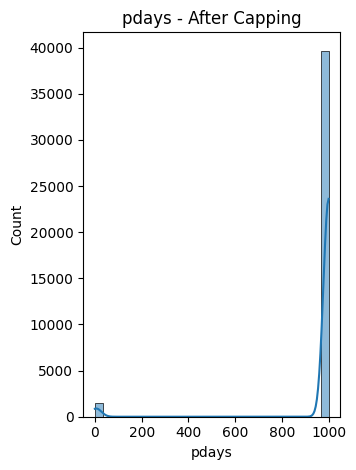

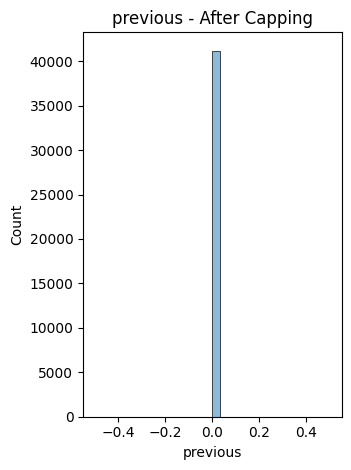

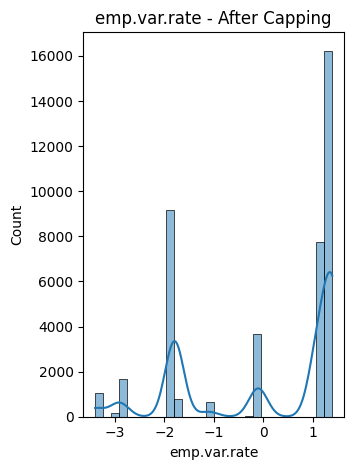

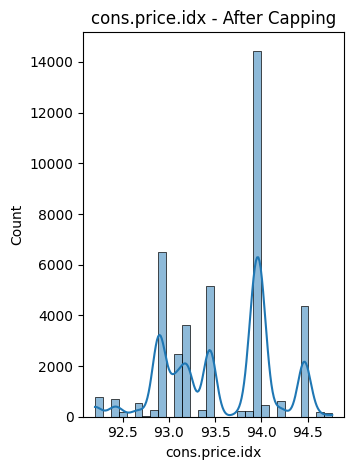

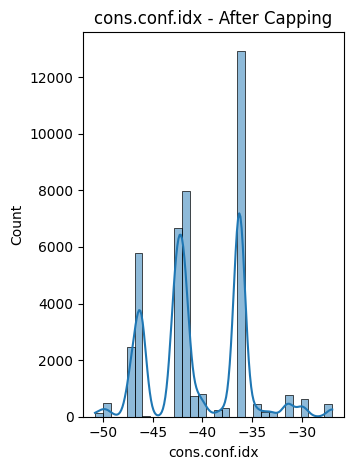

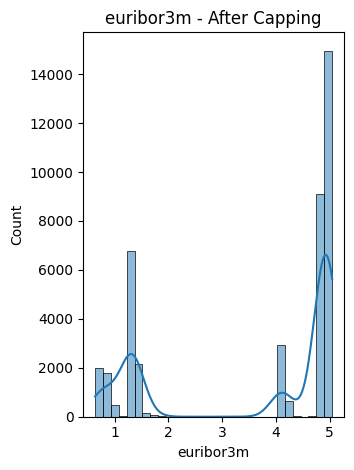

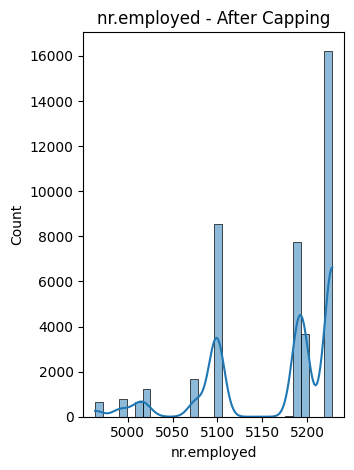

In [110]:
for col in numeric_features:
 plt.subplot(1,2,2)
 sns.histplot(df[col], bins=30, kde=True)
 plt.title(f'{col} - After Capping')

 plt.tight_layout()
 plt.show()

## **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

# Feature Selection for K-Means Clustering

Before applying K-Means, several variables were removed to ensure meaningful customer segmentation and to avoid data leakage.

The target variable (`y`) was excluded because K-Means is an unsupervised algorithm and does not use labeled outcomes.

The variable `duration` was removed because it is only known after the call is completed and strongly influences the target. Including it would introduce data leakage and produce unrealistic clusters.

Campaign-related variables (`contact`, `month`, `day_of_week`) were also excluded since they describe when and how the contact occurred, rather than intrinsic customer characteristics.

Additionally, macroeconomic indicators (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) were removed because they reflect the broader economic environment and are shared across many clients, rather than representing individual customer attributes.

The final dataset therefore focuses on demographic, financial, and historical interaction features to ensure meaningful customer segmentation.

In [111]:
columns_to_drop = [
    'y',
    'duration',
    'contact',
    'month',
    'day_of_week',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

df_kmeans = df.drop(columns=columns_to_drop)

Unknown values were handled based on logical assumptions.

For the variables default, housing, and loan, unknown values were replaced with "no" under the assumption that missing responses likely indicate absence of credit or loans.

For marital status, unknown values were replaced using the most frequent marital category within the same age group to preserve demographic consistency.

For education, unknown values were replaced using the most frequent education level within each job category to maintain logical alignment between occupation and education.

This approach minimizes bias while preserving meaningful structure for clustering.

In [112]:
# Make a copy to avoid modifying original
df_clean = df_kmeans.copy()

# -----------------------------
# DEFAULT → replace unknown with "no"
# -----------------------------
df_clean['default'] = df_clean['default'].replace('unknown', 'no')

# -----------------------------
# HOUSING → replace unknown with "no"
# -----------------------------
df_clean['housing'] = df_clean['housing'].replace('unknown', 'no')

# -----------------------------
# LOAN → replace unknown with "no"
# -----------------------------
df_clean['loan'] = df_clean['loan'].replace('unknown', 'no')


# -----------------------------
# MARITAL → fill by mode within age group
# -----------------------------

# Create age groups
df_clean['age_group'] = pd.cut(df_clean['age'],
                               bins=[0,30,40,50,60,100],
                               labels=['<30','30-40','40-50','50-60','60+'])

# Function to fill unknown marital by mode of that age group
def fill_marital(group):
    mode_value = group[group['marital'] != 'unknown']['marital'].mode()
    if len(mode_value) > 0:
        group.loc[group['marital'] == 'unknown', 'marital'] = mode_value[0]
    return group

df_clean = df_clean.groupby('age_group').apply(fill_marital)

# Drop temporary column
df_clean = df_clean.drop(columns=['age_group'])


# -----------------------------
# EDUCATION → fill by job mode
# -----------------------------

def fill_education(group):
    mode_value = group[group['education'] != 'unknown']['education'].mode()
    if len(mode_value) > 0:
        group.loc[group['education'] == 'unknown', 'education'] = mode_value[0]
    return group

df_clean = df_clean.groupby('job').apply(fill_education)


print("Unknown values handled according to your strategy.")

Unknown values handled according to your strategy.


/tmp/ipython-input-815527060.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean = df_clean.groupby('age_group').apply(fill_marital)
/tmp/ipython-input-815527060.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('age_group').apply(fill_marital)
/tmp/ipython-input-815527060.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the oper

In [113]:

# Keep only those that exist in df_clean
categorical_features = [col for col in categorical_features if col in df_clean.columns]

# One-hot encode
df_clean = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)


print("One-hot encoding applied. Columns now numeric.")

One-hot encoding applied. Columns now numeric.


In [114]:
from sklearn.preprocessing import StandardScaler

# List of numeric features we want to scale
numeric_features = ['age','duration','campaign','pdays','previous',
                    'emp.var.rate','cons.price.idx','cons.conf.idx',
                    'euribor3m','nr.employed']

# Keep only the ones that are still in the dataframe
numeric_features = [col for col in numeric_features if col in df_clean.columns]

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df_clean[numeric_features] = scaler.fit_transform(df_clean[numeric_features])

# Check result
df_clean[numeric_features].describe().round(2)

,age,campaign,pdays,previous
count,41188.00,41188.00,41188.00,41188.0
mean,0.00,-0.00,-0.00,0.0
std,1.00,1.00,1.00,0.0
min,-2.26,-0.82,-5.15,0.0
25%,-0.78,-0.82,0.20,0.0
50%,-0.19,-0.18,0.20,0.0
75%,0.70,0.47,0.20,0.0
max,2.92,2.40,0.20,0.0


In [115]:
# Convert all boolean columns to integers
bool_cols = df_clean.select_dtypes('bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Verify
print(df_clean.dtypes)
all_numeric = df_clean.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all()
print("All features numeric?", all_numeric)

age                              float64
campaign                         float64
pdays                            float64
previous                         float64
job_blue-collar                    int64
job_entrepreneur                   int64
job_housemaid                      int64
job_management                     int64
job_retired                        int64
job_self-employed                  int64
job_services                       int64
job_student                        int64
job_technician                     int64
job_unemployed                     int64
job_unknown                        int64
marital_married                    int64
marital_single                     int64
education_basic.6y                 int64
education_basic.9y                 int64
education_high.school              int64
education_illiterate               int64
education_professional.course      int64
education_university.degree        int64
default_yes                        int64
housing_yes     

In [116]:
# Check for missing values
missing_counts = df_clean.isnull().sum()
print("Missing values per column:\n", missing_counts)

# Check data types
print("\nData types:\n", df_clean.dtypes)

# Verify all features are numeric
all_numeric = df_clean.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all()
print("\nAll features numeric?", all_numeric)

Missing values per column:
 age                              0
campaign                         0
pdays                            0
previous                         0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_professional.course    0
education_university.degree      0
default_yes                      0
housing_yes                      0
loan_yes                         0
poutcome_nonexistent             0
poutcome_success           

                                   age  campaign     pdays  previous  \
job          age_group                                                 
student      <30       40372 -1.178714 -0.177540 -5.116381       0.0   
admin.       30-40     10741 -0.685094 -0.177540  0.195414       0.0   
services     50-60     39367  1.783007  1.757330  0.195414       0.0   
admin.       50-60     9370   1.091939  2.402287  0.195414       0.0   
blue-collar  30-40     17526  0.005974  1.757330  0.195414       0.0   
             40-50     17304  0.499595 -0.177540  0.195414       0.0   
admin.       <30       19243 -0.981266 -0.822497  0.195414       0.0   
management   40-50     8897   0.104698 -0.822497  0.195414       0.0   
blue-collar  <30       10356 -1.178714  1.757330  0.195414       0.0   
             30-40     26778 -0.685094 -0.822497  0.195414       0.0   
student      <30       14736 -1.079990  2.402287  0.195414       0.0   
services     50-60     5658   1.289387 -0.822497  0.195414      

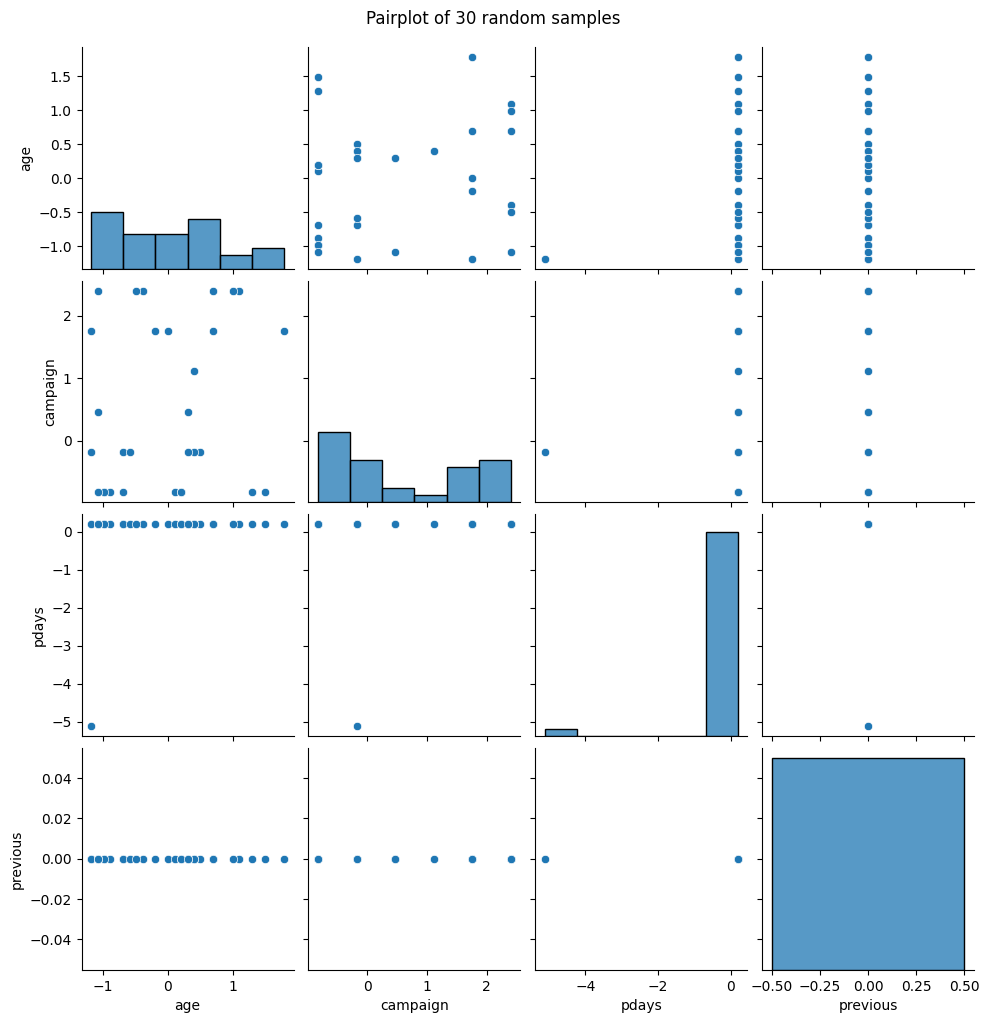

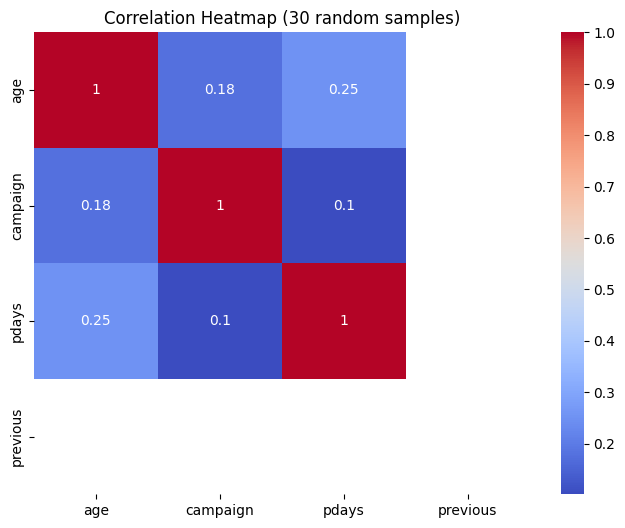

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1️⃣ Random sample of 30 rows
# -----------------------------
sample_df = df_clean.sample(30, random_state=42)
print(sample_df)

# -----------------------------
# 2️⃣ Quick visualization
# -----------------------------

# 2a. Pairplot of numeric features (scaled ones)
numeric_features = ['age','campaign','pdays','previous']  # main numeric features left
sns.pairplot(sample_df[numeric_features])
plt.suptitle("Pairplot of 30 random samples", y=1.02)
plt.show()

# 2b. Correlation heatmap of numeric features
plt.figure(figsize=(8,6))
sns.heatmap(sample_df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (30 random samples)")
plt.show()

### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [118]:
# Start with 3 clusters
initial_K = 3




In [119]:
kmeans = KMeans(n_clusters=initial_K, random_state=42)
kmeans.fit(df_clean)

KMeans(n_clusters=3, random_state=42)

In [120]:
# Cluster labels for each row
df_clean['cluster'] = kmeans.labels_

# Quick check
print(df_clean['cluster'].value_counts())

cluster
0    20588
2    13446
1     7154
Name: count, dtype: int64


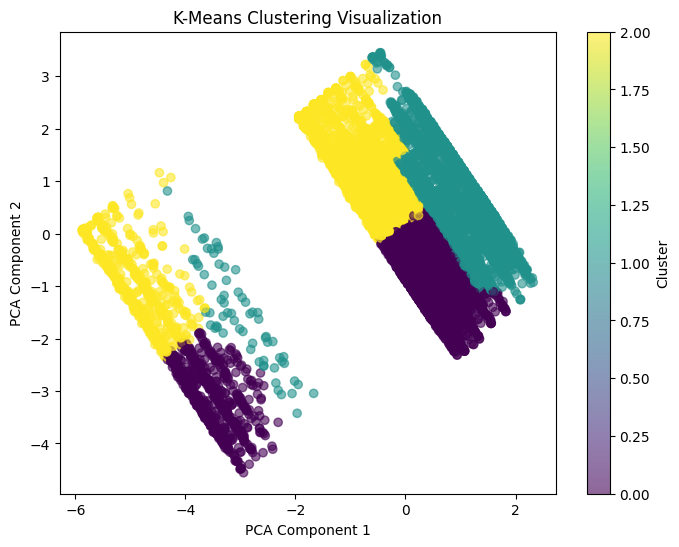

In [121]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_clean.drop(columns=['cluster']))


plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=df_clean['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering Visualization')
plt.colorbar(label='Cluster')
plt.show()

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

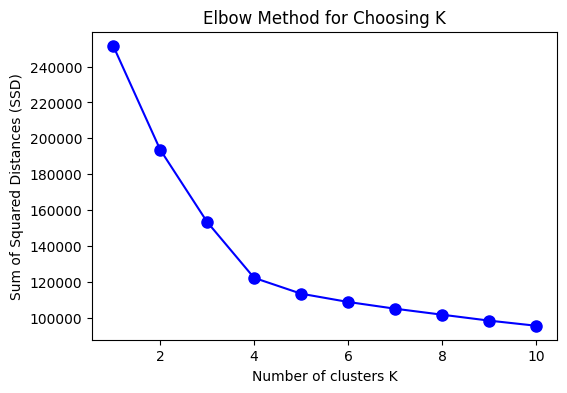

In [122]:
ssd = []
K_range = range(1, 11)  # test K from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clean)
    ssd.append(kmeans.inertia_)  # inertia = sum of squared distances to centroids

# Plot SSD vs K
plt.figure(figsize=(6,4))
plt.plot(K_range, ssd, 'bo-', markersize=8)
plt.xlabel('Number of clusters K')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Method for Choosing K')
plt.show()

**elbow point is 4**

In [123]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):  # silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_clean)
    score = silhouette_score(df_clean, labels)
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.247
K = 3, Silhouette Score = 0.272
K = 4, Silhouette Score = 0.307
K = 5, Silhouette Score = 0.225
K = 6, Silhouette Score = 0.207
K = 7, Silhouette Score = 0.157
K = 8, Silhouette Score = 0.136
K = 9, Silhouette Score = 0.152
K = 10, Silhouette Score = 0.156
